In [1]:
# notebooks/ sits one level down, so point at the lesson modules and data
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir(os.path.abspath('..'))
%matplotlib inline

# Lesson 7 — Where one compartment fails, and why that leads to PBPK

Lesson 02 showed the monkey curve bending on a log axis. Lesson 04
showed the residuals of a one-compartment fit marching in a systematic
pattern. Both say the same thing: the body is not one well-mixed bucket.

The minimal repair is a second compartment -- a tissue pool that the
chemical distributes into and comes back out of:


```text
central (blood)      <---k12/k21--->     peripheral (tissue)
     |
    k10 (elimination)
```

This lesson fits both models properly, compares them by LOO, and then
asks what the second compartment actually IS. That question is the one
PBPK exists to answer.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az

import plotting as P
from tk import load, iv_1comp, iv_2comp

P.setup()

SEED = 20260929
mk = load("PFOA_Male_primate")
mk = mk[mk.conc_mgL > 0]
DOSE = 10.0
animals = np.sort(mk.animal_id.unique())
idx = np.searchsorted(animals, mk.animal_id.values)
t, y = mk.time_d.values, np.log(mk.conc_mgL.values)
na = len(animals)


def one_compartment():
    with pm.Model() as m:
        mu_V = pm.Normal("mu_ln_V", np.log(0.2), 0.5)
        mu_k = pm.Normal("mu_ln_k", np.log(0.06), 0.7)
        sd_V = pm.HalfNormal("sd_ln_V", 0.3)
        sd_k = pm.HalfNormal("sd_ln_k", 0.5)
        V = pm.math.exp(mu_V + sd_V * pm.Normal("zV", 0, 1, shape=na))[idx]
        k = pm.math.exp(mu_k + sd_k * pm.Normal("zk", 0, 1, shape=na))[idx]
        sigma = pm.HalfNormal("sigma", 0.5)
        pm.Normal("obs", pt.log(DOSE / V) - k * t, sigma, observed=y)
        pm.Deterministic("half_life_pop", np.log(2) / pm.math.exp(mu_k))
    return m


def two_compartment():
    """Same hierarchy, but the analytical two-compartment solution.

    Parameterised by (V1, k10, k12, k21) rather than the eigenvalues,
    because those are the physiological quantities: V1 is the volume the
    dose mixes into immediately, k10 is elimination, and k12/k21 are
    exchange with tissue.
    """
    with pm.Model() as m:
        mu = {n: pm.Normal(f"mu_ln_{n}", np.log(v), s)
              for n, v, s in [("V1", 0.15, 0.5), ("k10", 0.08, 0.7),
                              ("k12", 0.3, 1.0), ("k21", 0.3, 1.0)]}
        sd = {n: pm.HalfNormal(f"sd_ln_{n}", 0.4) for n in mu}
        p = {n: pm.math.exp(mu[n] + sd[n] * pm.Normal(f"z_{n}", 0, 1, shape=na))
             for n in mu}
        V1, k10, k12, k21 = (p["V1"][idx], p["k10"][idx],
                             p["k12"][idx], p["k21"][idx])

        s = k10 + k12 + k21
        disc = pt.sqrt(pt.maximum(s ** 2 - 4 * k10 * k21, 1e-12))
        alpha, beta = (s + disc) / 2, (s - disc) / 2     # fast, slow
        c0 = DOSE / V1
        A = c0 * (alpha - k21) / (alpha - beta)
        B = c0 * (k21 - beta) / (alpha - beta)
        conc = A * pt.exp(-alpha * t) + B * pt.exp(-beta * t)

        sigma = pm.HalfNormal("sigma", 0.5)
        pm.Normal("obs", pt.log(pt.maximum(conc, 1e-12)), sigma, observed=y)

        # The reported half-life of a two-compartment model is the SLOW
        # (terminal) one, beta -- that is what governs long-term burden.
        s_pop = pm.math.exp(mu["k10"]) + pm.math.exp(mu["k12"]) + pm.math.exp(mu["k21"])
        d_pop = pt.sqrt(pt.maximum(
            s_pop ** 2 - 4 * pm.math.exp(mu["k10"]) * pm.math.exp(mu["k21"]), 1e-12))
        pm.Deterministic("half_life_terminal", np.log(2) / ((s_pop - d_pop) / 2))
        pm.Deterministic("half_life_alpha", np.log(2) / ((s_pop + d_pop) / 2))
        # Vss = V1*(1 + k12/k21): total volume once tissue has filled
        pm.Deterministic("Vss", pm.math.exp(mu["V1"]) *
                         (1 + pm.math.exp(mu["k12"] - mu["k21"])))
        pm.Deterministic("CL", pm.math.exp(mu["V1"] + mu["k10"]))
    return m


def fit(m, name):
    """Sample, and cache the result so you can re-analyse without refitting."""
    import os
    cache = f"trace_{name}.nc"
    if os.path.exists(cache):
        print(f"{name:18s} loaded from {cache}")
        return az.from_netcdf(cache)
    with m:
        i = pm.sample(2000, tune=2000, chains=4, random_seed=SEED,
                      target_accept=0.95, progressbar=False,
                      idata_kwargs={"log_likelihood": True})
    div = int(i.sample_stats.diverging.sum())
    print(f"{name:18s} divergences {div:4d}   "
          f"worst r-hat {float(az.rhat(i).to_array().max()):.4f}")
    i.to_netcdf(cache)
    return i

## A. Fit both models

In [3]:
print(f"PFOA, {na} monkeys, 10 mg/kg IV, {len(mk)} observations\n")
i1 = fit(one_compartment(), "1compartment")
i2 = fit(two_compartment(), "2compartment")

PFOA, 3 monkeys, 10 mg/kg IV, 43 observations

1compartment       loaded from trace_1compartment.nc


2compartment       loaded from trace_2compartment.nc


## B. Parameter estimates

In [4]:
print(az.summary(i1, var_names=["half_life_pop", "sigma"],
                 hdi_prob=0.95).to_string())
print()
print(az.summary(i2, var_names=["half_life_terminal", "half_life_alpha",
                                "Vss", "CL", "sigma"],
                 hdi_prob=0.95).to_string())

                 mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
half_life_pop  13.980  4.854     6.054     23.768      0.093    0.115    2753.0    3803.0    1.0
sigma           0.477  0.056     0.371      0.586      0.001    0.001    7710.0    4872.0    1.0

                      mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
half_life_terminal  19.769  5.360    11.045     30.604      0.084    0.129    3880.0    4521.0    1.0
half_life_alpha      5.284  1.149     3.080      7.569      0.018    0.013    3763.0    4479.0    1.0
Vss                  0.197  0.033     0.139      0.261      0.001    0.001    4372.0    4092.0    1.0
CL                   0.011  0.004     0.004      0.019      0.000    0.000    3526.0    3924.0    1.0
sigma                0.198  0.025     0.153      0.249      0.000    0.000    7133.0    5953.0    1.0


## C. Which model predicts better? (LOO)

In [5]:
comp = az.compare({"1-compartment": i1, "2-compartment": i2}, ic="loo")
print(comp.to_string())

winner = comp.index[0]
diff, dse = comp.elpd_diff.iloc[1], comp.dse.iloc[1]
print(f"\n   {winner} wins by {diff:.1f} +/- {dse:.1f} elpd")
print(f"   ratio {diff/max(dse,1e-9):.1f} standard errors "
      f"-- {'decisive' if diff > 4*dse else 'not decisive'}")

               rank   elpd_loo      p_loo  elpd_diff  weight        se      dse  warning scale
2-compartment     0   2.600001  10.054042   0.000000     1.0  4.760022  0.00000     True   log
1-compartment     1 -35.791290   9.717468  38.391291     0.0  6.829674  6.96725     True   log

   2-compartment wins by 38.4 +/- 7.0 elpd
   ratio 5.5 standard errors -- decisive


/tmp/claude-0/-home-user-chiu--2022-rerun/1d01819e-a495-5908-9e68-336af60a83fc/scratchpad/venv/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/tmp/claude-0/-home-user-chiu--2022-rerun/1d01819e-a495-5908-9e68-336af60a83fc/scratchpad/venv/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to hap

## D. Figures


Figures



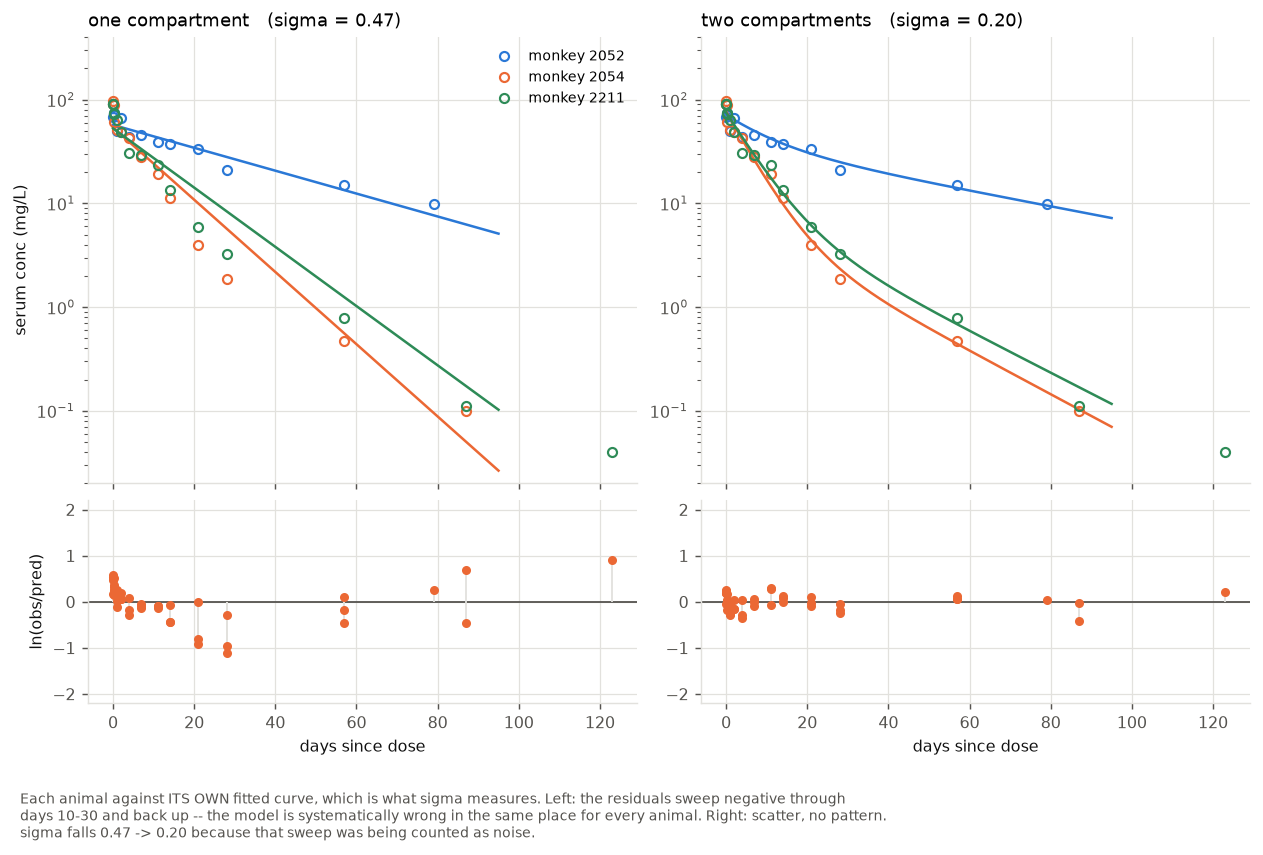

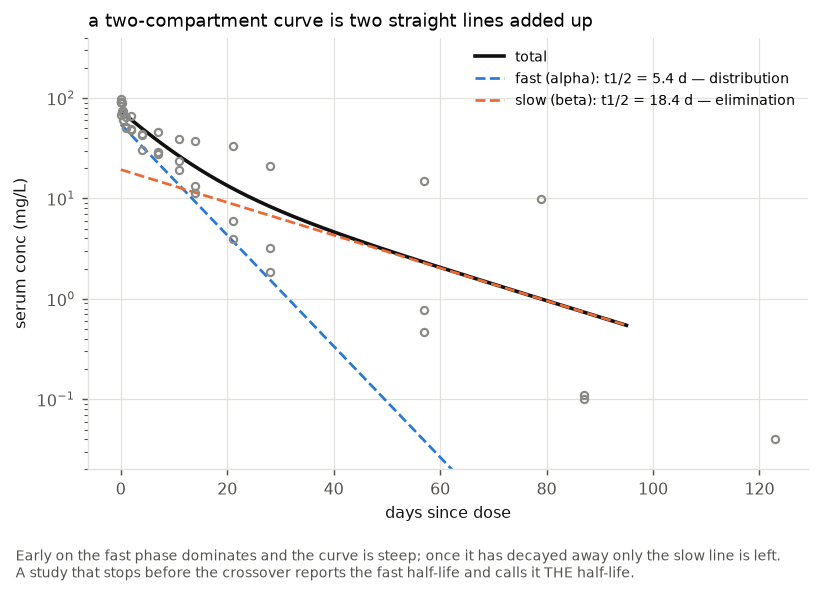

'/home/user/chiu__2022_rerun/tk_learning/figures/07_two_phases.png'

In [6]:
print("\nFigures\n")
grid = np.linspace(0.02, 95, 400)

def per_animal(idata, names):
    """Reconstruct each animal's own parameters from the non-centred
    posterior: p_i = exp(mu + sd*z_i), medianed over draws."""
    out = {}
    for n in names:
        mu = idata.posterior[f"mu_ln_{n}"].values[..., None]
        sd = idata.posterior[f"sd_ln_{n}"].values[..., None]
        z = idata.posterior[f"z{'_' if n not in ('V', 'k') else ''}{n}"].values
        out[n] = np.exp(np.median(mu + sd * z, axis=(0, 1)))
    return out

p1 = per_animal(i1, ["V", "k"])
p2 = per_animal(i2, ["V1", "k10", "k12", "k21"])

def curves(which, tt, j):
    if which == 1:
        return iv_1comp(tt, DOSE, p1["V"][j], p1["k"][j])
    return iv_2comp(tt, DOSE, p2["V1"][j], p2["k10"][j],
                    p2["k12"][j], p2["k21"][j])

fig, axes = plt.subplots(2, 2, figsize=(9.6, 5.8), sharex=True,
                         height_ratios=[2.2, 1], constrained_layout=True)
for col, (which, name) in enumerate([(1, "one compartment"),
                                     (2, "two compartments")]):
    a, b = axes[0, col], axes[1, col]
    res_all, t_all = [], []
    for j, (aid, c) in enumerate(zip(animals, P.CYCLE)):
        m = mk.animal_id.values == aid
        P.data_points(a, t[m], np.exp(y[m]), color=c,
                      label=f"monkey {aid}" if col == 0 else None)
        # each animal gets its OWN fitted curve -- that is what the
        # hierarchy estimates, and what sigma is the scatter around
        a.plot(grid, curves(which, grid, j), color=c, lw=1.4)
        r = y[m] - np.log(curves(which, t[m], j))
        res_all.append(r); t_all.append(t[m])
    a.set(yscale="log", ylim=(0.02, 400))
    sg = float(np.median(
        (i1 if which == 1 else i2).posterior["sigma"]))
    a.set_title(f"{name}   (sigma = {sg:.2f})")
    if col == 0:
        a.set_ylabel("serum conc (mg/L)")
        a.legend(loc="upper right", fontsize=7.5)
    tt_, rr = np.concatenate(t_all), np.concatenate(res_all)
    b.axhline(0, color=P.SOFT, lw=1)
    b.vlines(tt_, 0, rr, color=P.GRID, lw=1)
    b.plot(tt_, rr, "o", color=P.ORANGE, ms=4)
    b.set(xlabel="days since dose", ylim=(-2.2, 2.2))
    if col == 0:
        b.set_ylabel("ln(obs/pred)")
P.save(fig, "07_one_vs_two.png",
       "Each animal against ITS OWN fitted curve, which is what "
       "sigma measures. Left: the residuals sweep negative through\n"
       "days 10-30 and back up -- the model is systematically wrong "
       "in the same place for every animal. Right: scatter, no "
       "pattern.\nsigma falls 0.47 -> 0.20 because that sweep was "
       "being counted as noise.")

# The two exponentials, separated. Use the POPULATION medians here,
# since this figure is about the shape of the model, not any animal.
V1m, k10m, k12m, k21m = np.exp([
    float(np.median(i2.posterior[f"mu_ln_{n}"]))
    for n in ["V1", "k10", "k12", "k21"]])
fig, ax = plt.subplots(figsize=(6.2, 4.0), constrained_layout=True)
sm = k10m + k12m + k21m
disc = np.sqrt(sm ** 2 - 4 * k10m * k21m)
al, be = (sm + disc) / 2, (sm - disc) / 2
c0 = DOSE / V1m
A = c0 * (al - k21m) / (al - be)
B = c0 * (k21m - be) / (al - be)
ax.plot(grid, A * np.exp(-al * grid) + B * np.exp(-be * grid),
        color=P.INK, lw=2.0, label="total")
ax.plot(grid, A * np.exp(-al * grid), "--", color=P.BLUE, lw=1.5,
        label=f"fast (alpha): t1/2 = {np.log(2)/al:.1f} d — distribution")
ax.plot(grid, B * np.exp(-be * grid), "--", color=P.ORANGE, lw=1.5,
        label=f"slow (beta): t1/2 = {np.log(2)/be:.1f} d — elimination")
for aid, c in zip(animals, P.CYCLE):
    d = mk[mk.animal_id == aid]
    P.data_points(ax, d.time_d, d.conc_mgL, color=P.GREY, label=None, ms=4)
ax.set(yscale="log", ylim=(0.02, 400), xlabel="days since dose",
       ylabel="serum conc (mg/L)")
ax.set_title("a two-compartment curve is two straight lines added up")
ax.legend(loc="upper right", fontsize=8)
P.save(fig, "07_two_phases.png",
       "Early on the fast phase dominates and the curve is steep; "
       "once it has decayed away only the slow line is left.\n"
       "A study that stops before the crossover reports the fast "
       "half-life and calls it THE half-life.")

Note the 'warning' column: True for both models. ArviZ is telling you

```text
that some observations have a Pareto k above 0.7, meaning the LOO
approximation is shaky for those points -- with 43 observations and
3 animals, dropping a single point really can move the posterior.
The ranking here is wide enough (5+ standard errors) to survive that,
but never report a marginal LOO difference with this flag set; rerun
the flagged points with az.reloo, or use k-fold.
```

### E. What the second compartment bought you

Look at sigma. In the one-compartment fit it has to absorb the
systematic curvature; in the two-compartment fit that curvature is
modelled, so sigma drops and the residuals stop marching. A drop in
sigma with a better LOO is the signature of a genuinely better
structural model, as opposed to one that is simply more flexible.

Look at the two half-lives. The fast (alpha) phase is distribution
into tissue; the slow (terminal) phase is what actually governs how
long the chemical stays in the body, and it is the number that should
be compared across species and across studies. A study that stopped
sampling during the alpha phase reports the alpha half-life and calls
it the half-life -- which is one concrete reason published PFAS
half-lives disagree (lesson 03, trap 1).

### F. And now the honest limitation

The two-compartment model fits. But ask what the peripheral
compartment IS, and there is no answer. It is a mathematical
container with a volume and two rate constants, fitted to blood data.
It cannot tell you:

- how much PFOA is in the liver versus the kidney
- what happens if you change the dose route
- what happens in a pregnant animal, or a child
- how to extrapolate from monkey to human other than by allometry,
  which the EPA paper showed fails for PFAS clearance
- why male and female rats differ 44-fold
Every one of those questions needs compartments that correspond to
real organs, with real blood flows, real volumes, and elimination
written as a transporter process rather than a rate constant. That is
PBPK, and it is the next step.

What carries over from these seven lessons:
- mass balance, dC/dt = in - out, is the entire idea; PBPK just has
  one such equation per organ
- first-order rates, half-life, clearance, AUC, steady state
- identifiability: PBPK has dozens of parameters and blood data
  that can constrain only a handful, so most are FIXED from
  physiology rather than fitted. Knowing which is which is the
  whole skill.
- the hierarchical Bayesian machinery, unchanged -- Chiu's human
  model and the EPA's animal models are both exactly this, and
  PBPK versions swap the ODE and keep the statistics

### Questions

1. Vss from the two-compartment fit should exceed V1. Why must that be true, and what does the gap mean physically?
1. The one-compartment half-life sits between the alpha and terminal half-lives. Explain why, in terms of what least squares (or the likelihood) is trading off.
1. LOO compares predictive accuracy, not truth. If the two-compartment model had won by less than 2*dse, what would you conclude, and what would you do?
1. The 2-compartment model has 4 population parameters plus 4 spreads against the 1-compartment's 2 plus 2, fitted to 43 points from 3 animals. What stops it from simply overfitting? (Two answers: one about LOO, one about priors.)

### Exercises

1. Refit both models on PFOS_Male_primate. Does the second compartment still win? PFOS distributes differently from PFOA.
1. Drop every observation after day 28 and refit. Does LOO still pick two compartments? This is the "how long must a study run" question, and you can answer it quantitatively.
1. Add a third compartment. At what point does LOO stop rewarding you? That boundary is where blood data alone runs out of information -- and it is precisely why PBPK has to import structure from physiology instead of learning it from the data.